<a href="https://colab.research.google.com/github/ValentinBarco/Aprendizaje-de-maquina/blob/master/Proyecto_Fina%3B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


##Prueba si el programa lee correctamente la imagen


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:9: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  if __name__ == '__main__':


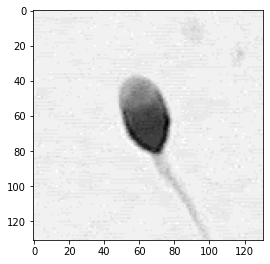

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

img_normal     = cv2.imread('/content/drive/MyDrive/Colab Notebooks/HuSHem/01_Normal/image_001.BMP',0)
plt.figure(figsize=(14,14))
plt.subplot(1,3,2)
plt.imshow(img_normal,cmap='gray')
plt.subplot(1,3,2)

##Cargo los Datasets con las imagenes

In [211]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage.transform import resize
from skimage import exposure
from skimage.io import imshow
Normal = '/content/drive/MyDrive/Colab Notebooks/HuSHem/01_Normal' 
Normal_Training = []


for img in os.listdir(Normal):
  img = cv2.imread(os.path.join(Normal,img))
  img = cv2.resize(img,(256,128),interpolation=cv2.INTER_AREA)
  fd = hog(img, orientations=9, pixels_per_cell=(16, 16),cells_per_block=(2, 2), multichannel=True) 
  fd = fd/fd.max()
  #fd = exposure.rescale_intensity(fd, in_range= (0,5));
  Normal_Training.append(fd)



In [93]:
Tapered = '/content/drive/MyDrive/Colab Notebooks/HuSHem/02_Tapered' 
Tapered_Training = []


for img in os.listdir(Tapered):
  img = cv2.imread(os.path.join(Tapered,img))
  img = cv2.resize(img,(256,128),interpolation=cv2.INTER_AREA)
  fd = hog(img, orientations=9, pixels_per_cell=(16, 16),cells_per_block=(2, 2), multichannel=True) 
  fd = fd/fd.max()
  #fd = exposure.rescale_intensity(fd, in_range= (0,5));
  Tapered_Training.append(fd)

In [94]:
Pyriform = '/content/drive/MyDrive/Colab Notebooks/HuSHem/03_Pyriform' 
Pyriform_Training = []


for img in os.listdir(Pyriform):
  img = cv2.imread(os.path.join(Pyriform,img))
  img = cv2.resize(img,(256,128),interpolation=cv2.INTER_AREA)
  fd = hog(img, orientations=9, pixels_per_cell=(16, 16),cells_per_block=(2, 2), multichannel=True) 
  fd = fd/fd.max()
  #fd = exposure.rescale_intensity(fd, in_range= (0,5));
  Pyriform_Training.append(fd)

In [95]:
Amorphous = '/content/drive/MyDrive/Colab Notebooks/HuSHem/04_Amorphous' 
Amorphous_Training = []


for img in os.listdir(Amorphous):
  img = cv2.imread(os.path.join(Amorphous,img))
  img = cv2.resize(img,(256,128),interpolation=cv2.INTER_AREA)
  fd = hog(img, orientations=9, pixels_per_cell=(16, 16),cells_per_block=(2, 2), multichannel=True) 
  fd = fd/fd.max()
  fd = exposure.rescale_intensity(fd, in_range= (0,5));
  Amorphous_Training.append(fd)

##Asigno los targets 



1.   Esperma Normal
2.   Esperma Tapered
3.   Esperma Pyriform
4.   Esperma Amorphous








In [96]:
import pandas as pd

Data_Normal = pd.DataFrame(Normal_Training)
target_Normal = pd.DataFrame([1]*len(Data_Normal))
Data_Tapered = pd.DataFrame(Tapered_Training)
target_Tapered = pd.DataFrame([2]*len(Data_Tapered))
Data_Pyriform = pd.DataFrame(Pyriform_Training)
target_Pyriform =pd.DataFrame([3]*len(Data_Pyriform))
Data_Amorphous = pd.DataFrame(Amorphous_Training)
target_Amorphous =pd.DataFrame([4]*len(Data_Amorphous))

Dataset = pd.concat([Data_Normal , Data_Tapered, Data_Pyriform, Data_Amorphous],ignore_index= True,axis=0)
target = pd.concat([target_Normal, target_Tapered , target_Pyriform, target_Amorphous],ignore_index= True,axis=0)

target.head

<bound method NDFrame.head of      0
0    1
1    1
2    1
3    1
4    1
..  ..
211  4
212  4
213  4
214  4
215  4

[216 rows x 1 columns]>

#Modelo: K Vecinos mas cercanos

###Calculo de n_vecinos para mayor presicion

In [179]:
#Importacion de librerias

from sklearn import neighbors
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.model_selection import train_test_split


#Separacion entre datos de entrenamiento y datos de prueba 

X_train, X_test, y_train, y_test = train_test_split(Dataset, target, test_size=0.2, random_state=3)

In [180]:
for n in range(1,10):
  Kvecinos = neighbors.KNeighborsClassifier(n_neighbors=n)
  Kvecinos.fit(X_train, y_train)
  y_pred = Kvecinos.predict(X_test)
  Score = precision_score(y_test, y_pred, average='micro')
  print("La Presicion del Modelo con " + str(n) + " vecinos es:",Score)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until


La Presicion del Modelo con 1 vecinos es: 0.6590909090909091
La Presicion del Modelo con 2 vecinos es: 0.6590909090909091
La Presicion del Modelo con 3 vecinos es: 0.6363636363636364


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until


La Presicion del Modelo con 4 vecinos es: 0.6363636363636364
La Presicion del Modelo con 5 vecinos es: 0.7045454545454546
La Presicion del Modelo con 6 vecinos es: 0.6818181818181818


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until


La Presicion del Modelo con 7 vecinos es: 0.6136363636363636
La Presicion del Modelo con 8 vecinos es: 0.6590909090909091
La Presicion del Modelo con 9 vecinos es: 0.6590909090909091


##Entrenamiento del Modelo con el N optimo

In [201]:
## Como podemos notar el modelo tiene mas presicion con n = 5

X_train, X_test, y_train, y_test = train_test_split(Dataset, target, test_size=0.2, random_state=3)

Kvecinos = neighbors.KNeighborsClassifier(n_neighbors=5)
Kvecinos.fit(X_train, y_train)

y_pred = Kvecinos.predict(X_test)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  


#Matiz de Confusion

Precision: 0.7045454545454546
Exactitud: 0.7045454545454546
Sensibilidad: 0.6987179487179488
Puntaje: 0.7045454545454546


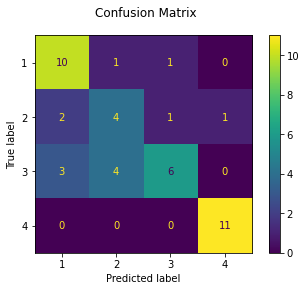

In [202]:
disp = metrics.plot_confusion_matrix(Kvecinos, X_test, y_test)
disp.figure_.suptitle("Confusion Matrix");



from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

Precision = precision_score(y_test, y_pred, average='micro')
Exactitud = accuracy_score(y_test,y_pred)
Sensibilidad = recall_score(y_test,y_pred,average='macro')
Puntaje = f1_score(y_test,y_pred,average = 'micro')
print('Precision: '+ str(Precision))
print('Exactitud: '+ str(Exactitud))
print('Sensibilidad: '+ str(Sensibilidad))
print('Puntaje: '+ str(Puntaje))

#Modelo: Bayes

In [193]:
from sklearn.naive_bayes import GaussianNB

Bayes = GaussianNB()
Bayes.fit(X_train, y_train)

y_pred = Bayes.predict(X_test)

/usr/local/lib/python3.7/dist-packages/sklearn/naive_bayes.py:206: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Precision: 0.6363636363636364


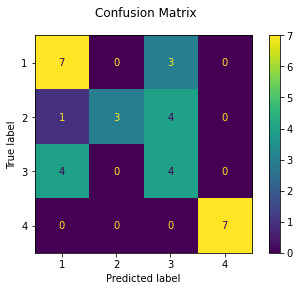

In [176]:
from sklearn.metrics import precision_score
disp = metrics.plot_confusion_matrix(Bayes, X_test, y_test)
disp.figure_.suptitle("Confusion Matrix")

Precision = precision_score(y_test, y_pred, average='micro')
print('Precision: '+ str(Precision))

#Modelo: Support Vector Machine

In [189]:

from sklearn.model_selection import train_test_split
from sklearn import svm, metrics
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
 
X_train, X_test, y_train, y_test = train_test_split(Dataset, target, shuffle = True, test_size=0.15, random_state=1)

clasificador = svm.SVC(kernel = 'linear')
clasificador.fit(X_train, y_train)

y_pred = clasificador.predict(X_test)


/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Precision: 0.8484848484848485


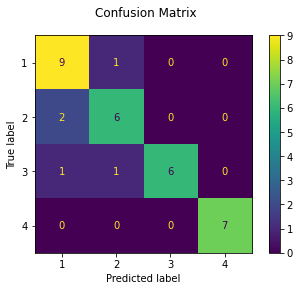

In [190]:
disp = metrics.plot_confusion_matrix(clasificador, X_test, y_test)
disp.figure_.suptitle("Confusion Matrix")


Precision = precision_score(y_test, y_pred, average='micro')


print('Precision: '+ str(Precision))


#Modelo: Arbol de clasificacion

```
# Esto tiene formato de código
```



In [191]:
from sklearn.tree import DecisionTreeClassifier


Arbol = DecisionTreeClassifier(criterion = 'entropy')
Arbol.fit(X_train, y_train)
y_pred = Arbol.predict(X_test)

Precision: 0.696969696969697


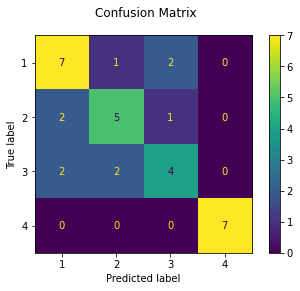

In [192]:
from sklearn.metrics import precision_score
disp = metrics.plot_confusion_matrix(Arbol, X_test, y_test)
disp.figure_.suptitle("Confusion Matrix")

Precision = precision_score(y_test, y_pred, average='micro')
print('Precision: '+ str(Precision))

#Modelo: Bosque Aleatorio de Clasificacion

In [199]:

from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(Dataset, target, shuffle = True, test_size=0.15, random_state=1)

Bosque = RandomForestClassifier(n_estimators=10, criterion = 'entropy')
Bosque.fit(X_test,y_test);
y_pred = Bosque.predict(X_test)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  import sys


Precision: 1.0


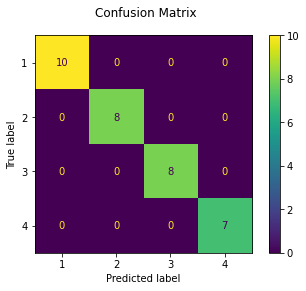

In [200]:
disp = metrics.plot_confusion_matrix(Bosque, X_test, y_test)
disp.figure_.suptitle("Confusion Matrix")

Precision = precision_score(y_test, y_pred, average='micro')
print('Precision: '+ str(Precision))